## Color Palettes

In [32]:
import colorsys

def generate_color_palette(base_color, num_steps):
    # Convert the base color from hex to RGB
    r, g, b = tuple(int(base_color[i:i+2], 16) for i in (0, 2, 4))
    
    # Generate the RGB colors for the palette in reverse order
    colors = []
    for i in range(num_steps - 1, -1, -1):
        percent = i / (num_steps - 1)
        rgb = colorsys.rgb_to_hls(r/255, g/255, b/255)
        new_rgb = colorsys.hls_to_rgb(rgb[0], percent, rgb[2])
        new_color = tuple(int(c * 255) for c in new_rgb)
        colors.append(new_color)
    
    # Convert the RGB colors to hex in reverse order
    palette = {}
    for i, rgb in enumerate(colors[::-1]):
        hex_code = '#%02x%02x%02x' % rgb
        percent = (num_steps - i - 1) * (100 / (num_steps - 1))
        palette[percent] = hex_code
    
    # Add the endpoints at 0% and 100%
    palette[0] = '#ffffff'
    palette[100] = '#000000'
    
    return palette


In [33]:
import matplotlib.pyplot as plt

100.0%		 #000000
90.0%		 #323300
80.0%		 #656600
70.0%		 #989900
60.0%		 #cbcc00
50.0%		 #feff00
40.0%		 #feff32
30.0%		 #feff65
20.0%		 #feff99
10.0%		 #fefecc
0.0%		 #ffffff


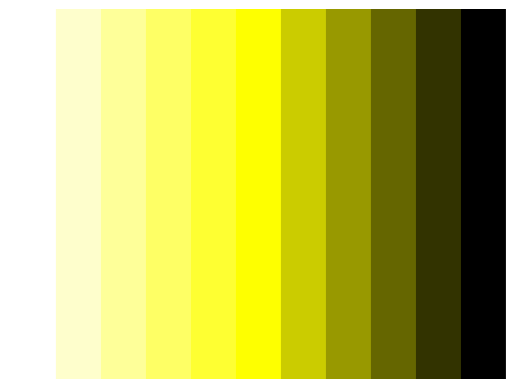

In [35]:
# Example usage
base_color = 'ffff00'
num_steps = 11

color_palette = generate_color_palette(base_color, num_steps)

# Print the color palette
for percent, hex_code in color_palette.items():
    plt.plot([percent, percent], [0, 1], color=hex_code, linewidth=33)
    print(f'{percent}%\t\t {hex_code}')
    
# Display the color samples
plt.axis('off')
plt.show()

In [23]:
import json

# Read JSON data from a file
with open('./Monochrome(clhxui32a047a01qnczfz94b6)/style.json') as f:
    data = json.load(f)

# # Print the entire JSON structure
# print(json.dumps(data, indent=4))


In [24]:
import json

# Read JSON data from a file
with open('./Monochrome(clhxui32a047a01qnczfz94b6)/style.json') as f:
    data = json.load(f)
    
# Extract the "votos-dptos" and "votos-circs" layers
votos_dptos = None
votos_circs = None
for layer in data['layers']:
    if layer.get('id') == 'votos-dptos':
        votos_dptos = layer
    elif layer.get('id') == 'votos-circs':
        votos_circs = layer

print(json.dumps(votos_dptos, indent=4))


{
    "id": "votos-dptos",
    "type": "fill",
    "source": "composite",
    "source-layer": "votos-dptos",
    "layout": {},
    "paint": {
        "fill-opacity": [
            "interpolate",
            [
                "linear"
            ],
            [
                "zoom"
            ],
            8,
            0,
            9,
            1,
            10,
            1,
            11,
            0
        ],
        "fill-color": [
            "interpolate",
            [
                "linear"
            ],
            [
                "get",
                "('BLTG15n', 1, 'PERON')"
            ],
            0.1985020786523819,
            "#ff0a0a",
            0.6761865019798279,
            "#9fd6ab"
        ]
    }
}


['interpolate', ['linear'], ['get', "('BLTG15n', 1, 'PERON')"], 0.0, '#000000', 0.1, '#0a2828', 0.2, '#145151', 0.3, '#1e7a7a', 0.4, '#28a3a3', 0.5, '#32cbcc', 0.6, '#5bd6d6', 0.7, '#84e0e0', 0.8, '#adeaea', 0.9, '#d6f4f4', 1.0, '#ffffff']


In [26]:
new_fill_color

['interpolate',
 ['linear'],
 ['get', "('BLTG15n', 1, 'PERON')"],
 0.0,
 '#000000',
 0.1,
 '#0a2828',
 0.2,
 '#145151',
 0.3,
 '#1e7a7a',
 0.4,
 '#28a3a3',
 0.5,
 '#32cbcc',
 0.6,
 '#5bd6d6',
 0.7,
 '#84e0e0',
 0.8,
 '#adeaea',
 0.9,
 '#d6f4f4',
 1.0,
 '#ffffff']

In [28]:
import json

# Read JSON data from a file
with open('./Monochrome(clhxui32a047a01qnczfz94b6)/style.json') as f:
    data = json.load(f)


### Generate the color palette

# Example usage
base_color = '33cccc'
num_steps = 11

palette = generate_color_palette(base_color, num_steps)

# Convert the palette to the desired format
new_fill_color = [
    "interpolate",
    ["linear"],
    ["get", "('BLTG15n', 1, 'PERON')"],
]

for percent, hex_code in palette.items():
    new_fill_color.extend([percent / 100, hex_code])

# Print the new_fill_color
print(new_fill_color)


## Apply the color palette to the map and save the updated style.json file
# Find the "votos-dptos" layer
for layer in data['layers']:
    if layer.get('id') == 'votos-dptos':
        layer['paint']['fill-color'] = new_fill_color
    if layer.get('id') == 'votos-circs':
        layer['paint']['fill-color'] = new_fill_color

# Write the updated JSON back to the file
with open('./Monochrome(clhxui32a047a01qnczfz94b6)/style.json', 'w') as f:
    json.dump(data, f, indent=4)


['interpolate', ['linear'], ['get', "('BLTG15n', 1, 'PERON')"], 0.0, '#000000', 0.1, '#0a2828', 0.2, '#145151', 0.3, '#1e7a7a', 0.4, '#28a3a3', 0.5, '#32cbcc', 0.6, '#5bd6d6', 0.7, '#84e0e0', 0.8, '#adeaea', 0.9, '#d6f4f4', 1.0, '#ffffff']


In [4]:
# Print the value of a specific property
print(data['version'])

# Print nested properties
print(data['metadata']['mapbox:type'])
print(data['sources']['composite']['url'])


8
default
mapbox://mapbox.mapbox-streets-v8,matuteiglesias2.votos_pct


In [6]:
# Iterate over an array of objects
for layer in data['layers']:
    print(layer['id'])



land
national-park
landuse
waterway
water
land-structure-polygon
land-structure-line
aeroway-polygon
aeroway-line
building
votos-dptos
votos-circs
choropleth-fill
tunnel-path-trail
tunnel-path-cycleway-piste
tunnel-path
tunnel-steps
tunnel-pedestrian
tunnel-simple
road-path-trail
road-path-cycleway-piste
road-path
road-steps
road-pedestrian
road-simple
road-rail
bridge-path-trail
bridge-path-cycleway-piste
bridge-path
bridge-steps
bridge-pedestrian
bridge-case-simple
bridge-simple
bridge-rail
admin-1-boundary-bg
admin-0-boundary-bg
admin-1-boundary
admin-0-boundary
admin-0-boundary-disputed
road-label-simple
waterway-label
natural-line-label
natural-point-label
water-line-label
water-point-label
poi-label
airport-label
settlement-subdivision-label
settlement-minor-label
settlement-major-label
state-label
country-label
continent-label


In [7]:
# Iterate over key-value pairs in an object
for key, value in data['metadata'].items():
    print(key, value)

mapbox:type default
mapbox:origin monochrome-dark-v1
mapbox:sdk-support {'android': '11.0.0', 'ios': '11.0.0', 'js': '3.0.0'}
mapbox:autocomposite True
mapbox:variation monochrome-light-v1
mapbox:groups {'Transit, transit-labels': {'name': 'Transit, transit-labels', 'collapsed': True}, 'Choropleth, choropleth': {'collapsed': False, 'name': 'Choropleth, choropleth'}, 'Administrative boundaries, admin': {'name': 'Administrative boundaries, admin', 'collapsed': True}, 'Land & water, built': {'name': 'Land & water, built', 'collapsed': True}, 'Transit, bridges': {'name': 'Transit, bridges', 'collapsed': True}, 'Transit, surface': {'name': 'Transit, surface', 'collapsed': True}, 'Land & water, land': {'name': 'Land & water, land', 'collapsed': True}, 'Road network, bridges': {'name': 'Road network, bridges', 'collapsed': True}, 'Road network, tunnels': {'name': 'Road network, tunnels', 'collapsed': True}, 'Road network, road-labels': {'name': 'Road network, road-labels', 'collapsed': True},

In [8]:
# def find_value(key, value, json_data):
#     for k, v in json_data.items():
#         if k == key and v == value:
#             return True
#         elif isinstance(v, dict):
#             if find_value(key, value, v):
#                 return True
#         elif isinstance(v, list):
#             for item in v:
#                 if isinstance(item, dict):
#                     if find_value(key, value, item):
#                         return True
#     return False

# # Example usage
# result = find_value('type', 'background', data)
# print(result)  # True if 'type' with value 'background' is found


True


In [ ]:
import json

# Read the JSON data from a file
with open('style.json') as f:
    data = json.load(f)

# Extract the "choropleth-fill" layer
choropleth_fill = None
for layer in data['layers']:
    if layer.get('id') == 'choropleth-fill':
        choropleth_fill = layer
        break

# Extract the "data-viz/choropleth" component
data_viz_choropleth = data['components'].get('data-viz/choropleth')

# Extract the "votos-dptos" and "votos-circs" layers
votos_dptos = None
votos_circs = None
for layer in data['layers']:
    if layer.get('id') == 'votos-dptos':
        votos_dptos = layer
    elif layer.get('id') == 'votos-circs':
        votos_circs = layer

# Make modifications to the extracted objects if needed
if choropleth_fill:
    # Modify the "fill-color" property
    choropleth_fill['paint']['fill-color'] = [
        "interpolate",
        ["exponential", 1],
        ["get", "('PASO17n', 2, 'IZQUIERDA')"],
        0.024493303149938583,
        "hsl(295, 78%, 73%)",
        0.10949573665857315,
        "hsl(235, 86%, 60%)"
    ]

if data_viz_choropleth:
    # Modify the "choroplethLabelDataField" property
    data_viz_choropleth['choroplethLabelDataField'] = "('NEW_FIELD', 1, 'LABEL')"

# Print the modified objects
print(json.dumps(choropleth_fill, indent=4))
print(json.dumps(data_viz_choropleth, indent=4))
print(json.dumps(votos_dptos, indent=4))
print(json.dumps(votos_circs, indent=4))
